In [57]:
%reset
import ldax_processing as ldax
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Ellipse
import matplotlib as mpl
from scipy.optimize import curve_fit, minimize, fsolve
from scipy.stats import chi2, norm, skewnorm
import scipy.optimize as opt
import math
from scipy.differentiate import hessian as scipy_hessian
from functools import partial

In [58]:
def generateStats(data_path, fName, stdCutoff, triggerCutoff):
    # set data_path and fName variables apprpriately
    # Uncomment this line for bin/zipped files
    #s_raw = np.load(f'{data_path}/{fName}')['data']

    # For filing npz files
    s_raw, meta = ldax.Read_DDC10_fName(f'{data_path}/{fName}')

    s_raw = s_raw.astype(float)

    # Baseline Subtraction
    d = {}
    num_baseline_average = 100
    d['ba_l'] = s_raw[:,:,:num_baseline_average].mean(axis=-1)
    d['ba_r'] = s_raw[:,:,(-num_baseline_average):].mean(axis=-1)
    d['bs_l'] = s_raw[:,:,:num_baseline_average].std(axis=-1)
    d['bs_r'] = s_raw[:,:,(-num_baseline_average):].std(axis=-1)
    d['ba'] = 0.5 * (d['ba_l'] + d['ba_r'])
    s_raw = s_raw - d['ba'][:,:,np.newaxis]

    # FFT filtering
    bw = 10. # MHz
    sampling_rate = 100. # MHz
    s_filt_RC = np.empty_like(s_raw)
    # Current filter passes signal through 2 low pass (10 MHz bw) and 1 boxcar (7 samples width) filter
    for k in range(len(s_raw)):
        s_filt_RC[k,:,:] = ldax.lowpass_RC(s_raw[k,:,:], bw/sampling_rate, n=2)
        s_filt_RC[k,:,:] = ldax.avebox(s_filt_RC[k,:,:],7)

    cuts = {}
    chPeaks = {}

    # Only uncomment the max height deviation code for dealing with real waveforms
    pStart = 450 # pulse start sample
    pStop = 550  # pulse stop sample
    # pStart:pStop
    maxHeight = np.max(s_filt_RC[:,:,pStart:pStop], axis=-1)


    for k in range(meta['numChannels']):
        # Trigger Cut - Only use if no random trigger already avaliable
        cuts['trigger' + str(k)] = (maxHeight[k,:] > triggerCutoff)
        # Find two peaks per event
        chPeaks['ch' + str(k)] = ldax.find_peaks(s_filt_RC[k,:,:], n=2)
        # Full length pulse width
        chPeaks['ch' + str(k)]['pulseWidth'] = chPeaks['ch' + str(k)]['h0_r_samp'] - chPeaks['ch' + str(k)]['h0_l_samp']
        # AFT75-25
        chPeaks['ch' + str(k)]['aft75-25'] = chPeaks['ch' + str(k)]['a75_samp'] - chPeaks['ch' + str(k)]['a25_samp']
    
    return cuts, chPeaks, s_filt_RC, d, s_raw

# Go through waveforms directly
# Plots produce isolate triggered region - (450 - 550 sample)
def look_waveforms(waveform, cuts, num, end1=0, end2=1000):
    plt.close()
    fig, axs = plt.subplots(len(waveform), figsize=(10, 7))
    fig.suptitle("Event %d" % num)
    if cuts is None:
        cutWaveforms = waveform[:,:,:]
    else:
        cutWaveforms = waveform[:,cuts,:]
    for k in range(len(waveform)):
        axs[k].plot(cutWaveforms[k,num,end1:end2])
        axs[k].axhline(y=3, color='orange')
        axs[k].axvline(x=450, color='red')
        axs[k].axvline(x=550, color='red')
        axs[k].set_xlabel("Samples")
        axs[k].set_ylabel("adcc")
    plt.show()

In [59]:
# Enter whatever data path data is stored at here
data_path = "/Users/tarzanzhu/Documents"
fNames = '2025-09-26-templateData.bin.gz'
processedData = generateStats(data_path, fNames, 1.6, 3)

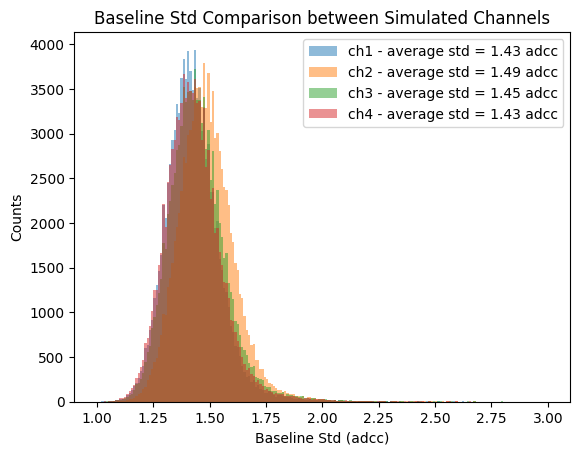

In [60]:
def comparebs(data1, data2, channel, cutoff):
    # Show what channels have what baseline std
    for i in range (4):
        plt.hist(data1[3]['bs_r'][channel+i,:], bins = np.arange(1, 3.01, 0.01), alpha = 0.5, label="ch%d - average std = %.2f adcc" % (i+1, np.mean(data1[3]['bs_r'][channel+i,:])))
    # See what events are cut from the cutoff defined
    #plt.axvline(x=cutoff, color='red', label="Right Events Cut")
    plt.ylabel("Counts")
    plt.xlabel("Baseline Std (adcc)")
    plt.title("Baseline Std Comparison between Simulated Channels")
    plt.legend()
    plt.show()

comparebs(processedData, processedData, 0, 0)

In [ ]:
def randnCov(covmat, mu=None, n=1, U=None, eVals=None):
    """
    Generate a set of correlated random numbers that are drawn from a multidimensional Gaussian 
    with a specified covariance matrix.  The code works by first calculating a unitary operator 
    that transforms from the input basis (in which the random numbers are correlated) into the 
    eigenbasis of the covariance matrix.  In this eigenbasis, the covariance matrix is diagonal, 
    all random numbers in the set are uncorrelated, and the eigenvalues give the variances of 
    these uncorrelated random numbers.  Uncorrelated random numbers are generated in this basis 
    and then transformed back to the original basis, thus introducing the desired correlations 
    described by the given covariance matrix.
    
    Inputs:
        covmat: Covariance matrix that expresses all variable-variable correlations.  Must be
                a numpy array (not list, not a numpy matrix), must be square.  If numpy chokes
                when trying to calculate the eigenvalues and eigenvectors, so will this 
                function :-)
            mu: (optional) The means of each correlated random number.  Default is 0 for each.
                If non-zero means are desired, this input must be given as a 1-D numpy array 
                with length equal to the rank of the covariance matrix.
             n: (optional) Number of sets of these random numbers to generate.
             U: (optional) The unitary operator that diagonalizes the covariance matrix. In cases
                where this function is called repeated times using the same covariance matrix,
                you might want to calculate U outside the function so that the same repeated 
                eigenval/vect calculation doesn't have to be repeated over and over again.
         eVals: (optional) Eigenvalues of covmat.  Optional for the same reason U is.
                U AND EVALS MUST BOTH BE SPECIFIED OR NEITHER.
    Outputs:
      randsOut: Array of correlated random numbers.  If n=1, the output is a regular numpy 1-D 
                array, of length given by the dimension of the covariance matrix.  If n>1, this
                output is a 2-D array, with n rows, and number of columns given by the dimension 
                of the covmat.  In other words, each row is a correlated set of random numbers.  
                Each row is an independent set of these random numbers.
    
    2016.03.23 
    """
    # ------- <Input checking> ------- #
    assert isinstance(covmat, np.ndarray), "Covariance matrix must be a numpy array."
    assert len(covmat.shape)==2, "Input 'covmat' must be a 2-D matrix."
    assert covmat.shape[0]==covmat.shape[1], "Input 'covmat' must be a square matrix."
    if mu is not None:
        assert hasattr(mu, '__len__'), "Input 'mu' must be an array"
        if isinstance(mu,list):
            mu = np.array(mu)
        assert isinstance(mu, np.ndarray), "Input 'mu' must be a list or numpy array"
        assert len(mu.shape) == 1, "Input 'mu' must be 1-dimensional."
        assert len(mu)==covmat.shape[0], "If input 'mu' is given, its length must be equal to " + \
            "the rank of the covariance matrix."
    # ------- </Input checking> ------- #
    
    # Number of correlated random numbers (i.e. the dimension of the cov. matrix)
    numRands = covmat.shape[0]
    
    # The user can provide their own unitary transformation to save on computation time
    # in the case of repeated calls with the same covmat. Otherwise, it is calculated here.
    if U is None: 
        # Find the eigenvalues and eigenvectors of the covariance matrix
        eVals, eVects = np.linalg.eig(covmat)
        
        # Calculate the unitary operator that transforms from the input basis, into the
        # covariance matrix's eigenbasis.  Since only its transpose is used later on, I just
        # calculate the transpose-transformation directly.
        #U = eVects.T
        U_transpose = eVects
    else:
        U_transpose = U.T
    
    assert eVals is not None, "You must also specify the eigenvectors."
    
    if n==1:
        # Generate random numbers in the diagonal basis (no correlations, obviously)
        randsDiag = np.random.randn(numRands)*np.sqrt(eVals)
        # Rotate the random numbers into the original basis.
        randsOut  = np.dot(U_transpose, randsDiag)
        if mu is not None:
            randsOut += mu
    else:
        #randsDiag = np.random.randn(n,numRands)*np.tile(np.sqrt(eVals),[n,1])
        #randsOut  = (np.dot(U_transpose, randsDiag.T)).T
        randsDiag = np.random.randn(numRands,n)*np.tile(np.c_[np.sqrt(eVals)], [1,n])
        randsOut  = (np.dot(U_transpose, randsDiag)).T
        if mu is not None:
            randsOut += np.tile(mu,[n,1])
    return randsOut



def gaussian(x, mu, sigma, a):
    gaussian = np.exp(-((x - mu)**2) / (2 * sigma**2))
    return a*gaussian

def linearFit(x, a, b):
    return a*x + b

# Define NLL - gaussian
def negativeLogLikelihoodGaussian(params, counts, bins):
    mu = params[0]
    sigma = params[1]
    totalCount = params[2]
    binCdfs = norm.cdf(bins, loc=mu, scale=sigma)
    lambdas = totalCount*np.diff(binCdfs)
    return np.sum(-counts*np.log(lambdas)+lambdas)

# Define NLL - skew gaussian
def negativeLogLikelihoodSkewGaussian(params, counts, bins):
    mu = params[0]
    sigma = params[1]
    totalCount = params[2]
    skew = params[3]
    binCdfs = skewnorm.cdf(bins, skew, loc=mu, scale=sigma)
    lambdas = totalCount*np.diff(binCdfs)
    return np.sum(-counts*np.log(lambdas)+lambdas)

# Hessian Matrix Calc
def calculateHessian(func, x, epsilon, args=()):
    jac = opt.approx_fprime(x, func, epsilon, *args)
    npar = len(x)
    hessian = np.zeros((npar,npar))
    xp = 1.*x
    for i in range(npar):
        xx0 = 1.*x[i]
        xp[i] = xx0 + epsilon
        jac1 = opt.approx_fprime(xp, func, epsilon, *args)
        hessian[i, :] = (jac1 - jac)/epsilon
        xp[i] = xx0
    return hessian

# Calc Cov Matrix - Gaussian
def calcCovMatrixGaussian(result, counts, bins):
    hessian = calculateHessian(negativeLogLikelihoodGaussian, result.x, 10E-5, (counts, bins))
    hess_inv = np.linalg.inv(hessian)
    print("Parameter Errors from Self-Made Hessian Func")
    paramErrors = np.sqrt(np.diag(hess_inv))
    print(paramErrors)
    return paramErrors

# Calc Cov Matrix - Skew Gaussian
def calcCovMatrixSkewGaussian(result, counts, bins):
    hessian = calculateHessian(negativeLogLikelihoodSkewGaussian, result.x, 10E-5, (counts, bins))
    hessInv = np.linalg.inv(hessian)
    print("Parameter Errors from Self-Made Hessian Func")
    return hessInv


# Minimize NLL - gaussian
def minimizeNegLogLikelihoodGaussian(counts, bins, initialGuess):
    result = minimize(negativeLogLikelihoodGaussian,
                      x0=initialGuess,
                      args=(counts, bins),
                      )
    errors = calcCovMatrixGaussian(result, counts, bins)
    return result, errors

# Minimize NLL - gaussian
def minimizeNegLogLikelihoodSkewGaussian(counts, bins, initialGuess):
    result = minimize(negativeLogLikelihoodSkewGaussian,
                      x0=initialGuess,
                      args=(counts, bins),
                      )
    hessInv = calcCovMatrixSkewGaussian(result, counts, bins)
    return result, hessInv

# Skew Gaussian Sim
def generateSkewGaussianData(numOfPts, mu, sigma, skew):
    s = skewnorm.rvs(skew, loc=mu, scale=sigma, size=numOfPts)

    sampleMu = np.mean(s)
    sampleSigma = np.std(s)
    stepSize = 0.25*sampleSigma
    numOfStds = 2

    counts, bins = np.histogram(s, bins = np.arange(sampleMu-numOfStds*sampleSigma, sampleMu+numOfStds*sampleSigma+stepSize, stepSize))
    counts2, bins2, n = plt.hist(s, bins = np.arange(sampleMu-5*sampleSigma, sampleMu+5*sampleSigma+stepSize, stepSize))
    result, errors = minimizeNegLogLikelihoodSkewGaussian(counts, bins, [mu, sigma, numOfPts, skew])
    print("Parameter Results")
    print(result.x)
    fitMu = result.x[0]
    fitSigma = result.x[1]
    fitTotalCounts = result.x[2]
    fitSkew = result.x[3]

    lambdas = fitTotalCounts*skewnorm.cdf(bins, fitSkew, loc = fitMu, scale = fitSigma)
    lambdas = np.diff(lambdas)
    plt.stairs(lambdas, edges=bins)
    plt.plot((bins[:-1]+bins[1:])/2, lambdas)

    lambdas2 = fitTotalCounts*skewnorm.cdf(bins2, fitSkew, loc = fitMu, scale=fitSigma)
    lambdas2 = np.diff(lambdas2)
    plt.plot((bins2[:-1]+bins2[1:])/2, lambdas2)
    paramErrors = np.sqrt(np.diag(result.hess_inv))
    print("Parameter Errors from Minimize")
    print(paramErrors)
    print("Expected Error")
    print(np.std(s)/np.sqrt(len(s)))
    plt.axvline(x = deriveFitMaximumSkewGaussian(fitMu, fitSigma, fitSkew, sampleMu), color = 'green')
    print("Maximum is located at %.2f" % deriveFitMaximumSkewGaussian(fitMu, fitSigma, fitSkew, sampleMu))

    print(lambdas)
    print(fitTotalCounts*skewnorm.pdf(np.arange(sampleMu-numOfStds*sampleSigma, sampleMu+numOfStds*sampleSigma+stepSize, stepSize), fitSkew, loc = fitMu, scale = fitSigma))

    plt.plot(np.arange(sampleMu-5*sampleSigma, sampleMu+5*sampleSigma+stepSize, 0.01), fitTotalCounts*skewnorm.pdf(np.arange(sampleMu-5*sampleSigma, sampleMu+5*sampleSigma+stepSize, 0.01), fitSkew, loc = fitMu, scale = fitSigma), label=("Gaussian Fit in Fit Region"))
    plt.legend()

    plt.xlabel("Randomly Generated Values")
    plt.ylabel("Counts")
    plt.show()

# Gaussian Sim
def generateGaussianData(numOfPts, mu, sigma):
    s = norm.rvs(loc=mu, scale=sigma, size=1000)

    sampleMu = np.mean(s)
    sampleSigma = np.std(s)
    counts, bins = np.histogram(s, bins = np.arange(sampleMu-2*sampleSigma, sampleMu+2*sampleSigma+1, 1))
    counts2, bins2, n = plt.hist(s, bins = np.arange(mu-5*sigma, mu+5*sigma, 1))
    result, errors = minimizeNegLogLikelihoodGaussian(counts, bins, [mu, sigma, numOfPts])
    fitMu = result.x[0]
    fitSigma = result.x[1]
    fitTotalCounts = result.x[2]

    lambdas = fitTotalCounts*norm.cdf(bins, loc = fitMu, scale=fitSigma)
    lambdas = np.diff(lambdas)
    print(lambdas)
    plt.stairs(lambdas, edges=bins)
    plt.plot((bins[:-1]+bins[1:])/2, lambdas)

    paramErrors = np.sqrt(np.diag(result.hess_inv))
    print("Parameter Errors from Minimize")
    print(paramErrors)
    print("Expected Error")
    print(np.std(s)/np.sqrt(len(s)))

    #plt.plot(np.arange(sampleMu-3*sampleSigma, sampleMu+3*sampleSigma+1, 5), totalCounts*norm.pdf(np.arange(sampleMu-3*sampleSigma, sampleMu+3*sampleSigma+1, 5), loc = fitMu, scale = fitSigma), label=("Gaussian Fit in Fit Region"))
    #plt.plot(np.arange(sampleMu-5*sampleSigma, sampleMu-3*sampleSigma, 5), totalCounts*norm.pdf(np.arange(sampleMu-5*sampleSigma, sampleMu-3*sampleSigma, 5), loc = fitMu, scale = fitSigma), label=("Gaussian Fit Outside Fit Region"), color='orange', linestyle = '--')
    #plt.plot(np.arange(sampleMu+3*sigma, sampleMu+5*sigma, 5), totalCounts*norm.pdf(np.arange(sampleMu+3*sigma, sampleMu+5*sigma, 5), loc = fitMu, scale = fitSigma), color='orange', linestyle = '--')
    #plt.plot(np.arange(mu-5*sigma, mu+5*sigma, 1), numOfPts*norm.pdf(np.arange(mu-5*sigma, mu+5*sigma, 10), loc = mu, scale = sigma), color='green', linestyle = '--', label='Original Gaussian')
    plt.xlabel("Randomly Generated Values")
    plt.ylabel("Counts")
    plt.legend()
    plt.show()

# # Numerical method for estimating skew gaussian maximum found on Wikipedia
# def deriveFitMaximumSkewGaussian(mu, sigma, skew, muError, sigmaError, skewError):
#     d = skew/np.sqrt(1+skew**2)
#     dError = skewError/(1+skew**2)**(3/2)
#     m0 = np.sqrt(2/np.pi)*d - (1-np.pi/4)*(np.sqrt(2/np.pi)*d)**3/(1-2*d**2/np.pi) - np.sign(skew)/2*np.exp(-2*np.pi/np.abs(skew))
#     fitMax = mu + sigma * m0
#     m0Error = np.sqrt(2/np.pi)*dError - (1-np.pi/4)*((np.sqrt(2/np.pi))**3*3*d**2/(1-2*d**2/np.pi)+4*d/np.pi*(np.sqrt(2/np.pi)*d)**3/(1-2*d**2/np.pi)**2)*dError - np.pi*np.sign(skew)/np.abs(skew)*np.exp(-2*np.pi/np.abs(skew))
#     fitMaxError = muError + sigmaError * 
#     return fitMax, fitMaxError

def modeSkewGaussian(x, alpha, mu, sigma):
    return (x-mu)/sigma*norm.cdf(alpha*(x-mu)/sigma) - alpha*norm.pdf(alpha*(x-mu)/sigma)

def deriveFitMaximumSkewGaussian(mu, sigma, alpha, estimate):
    sol = fsolve(modeSkewGaussian, estimate, args=(alpha,mu,sigma), fprime=None, full_output=0, 
                        col_deriv=0, xtol=1.49012e-08, maxfev=0, band=None, 
                            epsfcn=None, factor=100, diag=None)
    return sol
# Check Pulse Width vs Pulse Height and make cuts to isolate the SPE peak from the distribution
def comparePulseAreaAndHeight(data, voltage, stdCutoffs, channelList, speCutoffs, channel, titleChan, lowerPulseAreaCutoff, upperPulseAreaCutoff, fitGuess): 
    pulseAreaMean = {}
    channelsToTrigger = np.delete(np.copy(channelList), channel)
    randomTriggerCut = ["initializing array"]
    for tempChan in channelsToTrigger:
        if len(randomTriggerCut) == 1:
            randomTriggerCut = data[0]['trigger'+str(tempChan)]
        else:
            randomTriggerCut = randomTriggerCut | data[0]['trigger'+str(tempChan)]
    stdCut = (data[3]['bs_l'][channel,:] < stdCutoffs[channel]) & (data[3]['bs_r'][channel,:] < stdCutoffs[channel])

    #Remove events lowering than the boundAFT value and catgorize SPEs for pulse within bounds defined below (units in samples for all)
    boundAFT = 10
    leftBoundSPE = speCutoffs[0]
    rightBoundSPE = speCutoffs[1]
    
    # Cut definitions
    noiseCut = (data[1]['ch'+str(channel)]['pH'][0,:] < leftBoundSPE)
    speCut = (data[1]['ch'+str(channel)]['pH'][0,:] > leftBoundSPE) & (data[1]['ch'+str(channel)]['pH'][0,:] < rightBoundSPE)
    mpeCut = (data[1]['ch'+str(channel)]['pH'][0,:] > rightBoundSPE)
    aftCut = (data[1]['ch'+str(channel)]['aft75-25'][0,:] < boundAFT)
    pulseAreaCut = ((data[1]['ch'+str(channel)]['pA'][0,:] < upperPulseAreaCutoff) & (data[1]['ch'+str(channel)]['pA'][0,:] > lowerPulseAreaCutoff))

    # Get pulse area and height and plot the cut regions
    pulseArea = np.array(data[1]['ch'+str(channel)]['pA'][0,(stdCut & randomTriggerCut & aftCut)])
    pulseHeight = np.array(data[1]['ch'+str(channel)]['pH'][0,(stdCut & randomTriggerCut & aftCut)])

    plt.figure(figsize=(10, 6))
    plt.hist2d(pulseArea, pulseHeight, norm = mpl.colors.LogNorm(), bins=(np.arange(-20, 200, 2),np.arange(0,15,0.01)))
    plt.xlabel("Pulse Area (adcc samples)")
    plt.ylabel("Pulse Height (adcc)")
    plt.axhline(y=leftBoundSPE, color='red')
    plt.axhline(y=rightBoundSPE, color='red', label = 'Bounds for SPE Peak')
    #plt.axhline(y=boundAFT, color='orange', label="AFT Cut (events above line removed)")
    plt.colorbar()
    plt.title(voltage + " Pulse Height vs Pulse Area for SiPM Channel %d" % (titleChan))
    plt.legend()
    plt.show()


    # Output histograms in pulse area with relevant cuts applied
    cutPulseAreaData = data[1]['ch'+str(channel)]['pA'][0,(stdCut & randomTriggerCut & aftCut & speCut)]
    plt.figure(figsize=(10, 6))
    counts, bins = np.histogram(cutPulseAreaData, bins = np.arange(lowerPulseAreaCutoff, upperPulseAreaCutoff, 1))
    counts2, bins2, n = plt.hist(cutPulseAreaData, bins = np.arange(math.floor(np.min(cutPulseAreaData)), math.ceil(np.max(cutPulseAreaData)), 1), alpha = 0.5, histtype='step', label=('SPE (%.2f adcc < Pulse Height < %.2f adcc)'%(leftBoundSPE, rightBoundSPE)))

    # Labeling and Formatting
    plt.legend()
    plt.xlabel("Pulse Area (adcc samples)")
    plt.ylabel("Counts")
    plt.title(voltage+" Pulse Area Distribution for SiPM Channel %d" % (titleChan))

    # Producing Inv Hessian according to fit result
    initialGuess = fitGuess
    result, hessInv = minimizeNegLogLikelihoodSkewGaussian(counts, bins, initialGuess)
    print(hessInv)

    fitMu = result.x[0]
    fitSigma = result.x[1]
    fitTotalCounts = result.x[2]
    fitSkew = result.x[3]
    print("Values for Parameters")
    print(result)

    # Create a boolean mask for rows, excluding the 3rd row (index 2)
    row_mask = np.ones(hessInv.shape[0], dtype=bool)
    row_mask[2] = False

    # Create a boolean mask for columns, excluding the 3rd column (index 2)
    col_mask = np.ones(hessInv.shape[1], dtype=bool)
    col_mask[2] = False

    # Apply the masks to the matrix
    adjustedHessInv = hessInv[row_mask][:, col_mask]
    dataset = randnCov(adjustedHessInv, np.delete(result.x, 2), 1000)

    # Derive error bars on skew gaussian mode
    distOfModes = []
    for point in dataset:
        distOfModes.append(deriveFitMaximumSkewGaussian(point[0], point[1], point[2], point[0])[0])
    expectedMax = deriveFitMaximumSkewGaussian(fitMu, fitSigma, fitSkew, fitMu)
    lowMax = expectedMax - np.std(distOfModes)
    highMax= expectedMax + np.std(distOfModes)

    # Plot errorbars
    plt.axvline(x = lowMax, color = 'green', label = "Lower Limit of Maximum (%.2f adcc samples)" % lowMax[0])
    plt.axvline(x = highMax, color = 'blue', label = "Upper Limit of Maximum (%.2f adcc samples)" % highMax[0])
    plt.axvline(x = expectedMax, color = 'red', label = "Expected Maximum (%.2f adcc samples)" % expectedMax[0])
    print("Error Bar Range on Maximum - %.2f" % (highMax - lowMax)[0]) 
    print("Lower Boundary - %.4f" % lowMax[0])
    print("Upper Boundary - %.4f" % highMax[0])
    errorMax = np.std(distOfModes)

    # Plot skew gaussian fit
    lambdas2 = fitTotalCounts*skewnorm.cdf(bins2, fitSkew, loc = fitMu, scale=fitSigma)
    lambdas2 = np.diff(lambdas2)
    plt.plot((bins2[:-1]+bins2[1:])/2, lambdas2, color = 'orange', linestyle = '--', label = "Outside Fit Region")

    lambdas = fitTotalCounts*skewnorm.cdf(bins, fitSkew, loc = fitMu, scale = fitSigma)
    lambdas = np.diff(lambdas)
    plt.plot((bins[:-1]+bins[1:])/2, lambdas, color = 'orange', label = "Inside Fit Region")

    # Save plot and output data
    plt.ylim(0, 100+np.max(counts2))
    plt.legend()
    plt.savefig(data_path+"/ch"+str(titleChan)+"-"+voltage.replace(".", "")+"-gaussianfit.png")
    plt.show()
    return deriveFitMaximumSkewGaussian(fitMu, fitSigma, fitSkew, fitMu), errorMax

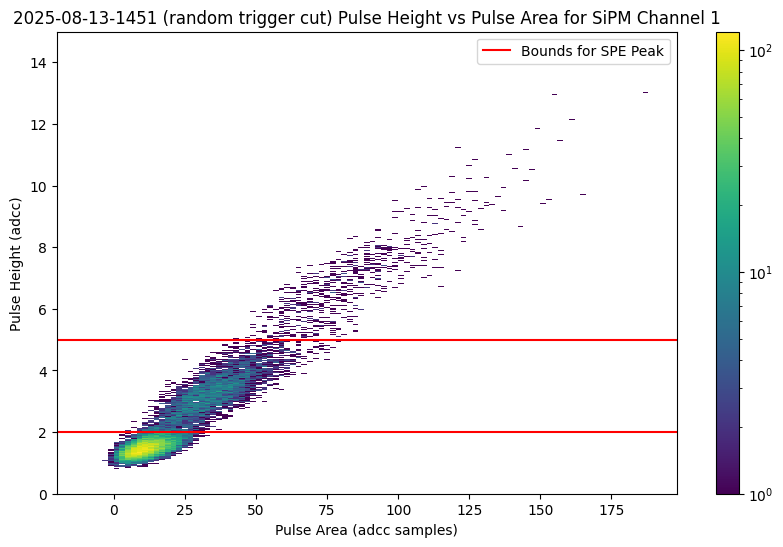

Parameter Errors from Self-Made Hessian Func
[[ 1.29923238e-01 -2.65200478e-01  7.46975952e-01 -1.31886147e-01]
 [-2.65200478e-01  7.40036301e-01 -1.68317969e+00  3.78688412e-01]
 [ 7.46975946e-01 -1.68317968e+00 -6.67724101e+02 -3.17501004e-01]
 [-1.31886147e-01  3.78688412e-01 -3.17501007e-01  2.12727858e-01]]
Values for Parameters
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -52111.34049428996
        x: [ 2.158e+01  1.915e+01  1.395e+04  2.533e+00]
      nit: 56
      jac: [-8.789e-03 -1.270e-02  0.000e+00  1.367e-02]
 hess_inv: [[ 3.514e-02 -5.541e-02 -7.568e-02 -1.983e-02]
            [-5.541e-02  1.434e-01  2.313e-01  7.296e-02]
            [-7.568e-02  2.313e-01  3.870e-01  1.261e-01]
            [-1.983e-02  7.296e-02  1.261e-01  4.681e-02]]
     nfev: 415
     njev: 83
Error Bar Range on Maximum - 0.83
Lower Boundary - 30.7733
Upper Boundary - 31.6044


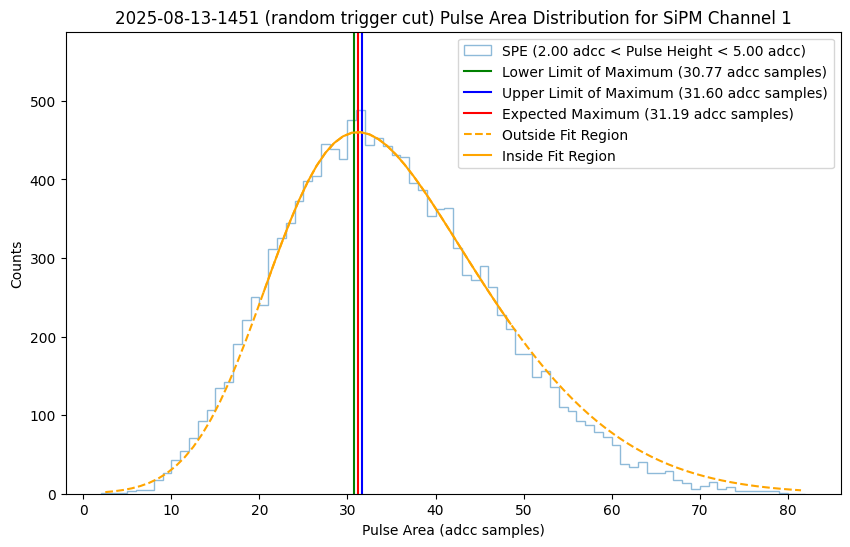

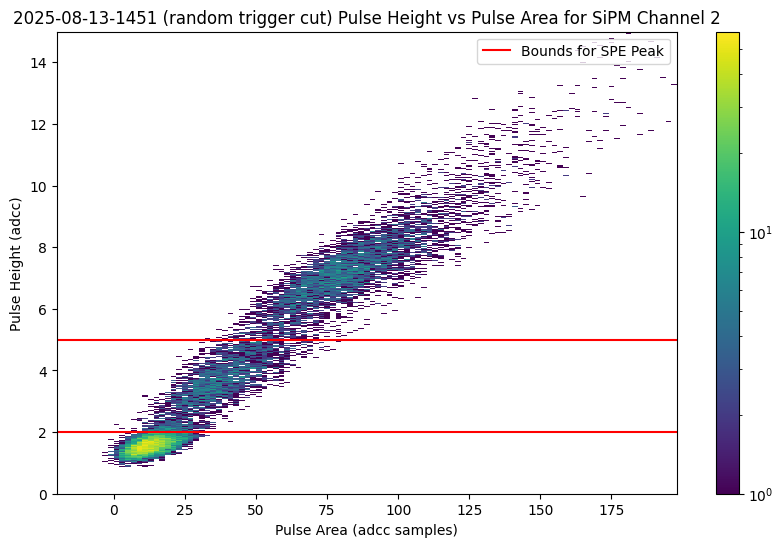

Parameter Errors from Self-Made Hessian Func
[[ 6.79763436e-01 -8.94924444e-01 -3.75381430e+00 -2.46507247e-01]
 [-8.94924444e-01  1.29472296e+00  7.26930543e+00  3.44250750e-01]
 [-3.75381427e+00  7.26930537e+00  1.47873009e+03  1.27283592e+00]
 [-2.46507247e-01  3.44250750e-01  1.27283593e+00  9.89917708e-02]]
Values for Parameters
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -40217.664350508465
        x: [ 2.236e+01  2.109e+01  1.194e+04  1.795e+00]
      nit: 74
      jac: [ 0.000e+00  4.883e-04  4.883e-04  1.953e-03]
 hess_inv: [[ 6.524e-03  2.457e-03 -7.495e-03 -1.480e-03]
            [ 2.457e-03  8.783e-03 -9.582e-03 -1.647e-03]
            [-7.495e-03 -9.582e-03  2.185e-02 -4.744e-03]
            [-1.480e-03 -1.647e-03 -4.744e-03  7.866e-03]]
     nfev: 475
     njev: 95
Error Bar Range on Maximum - 0.89
Lower Boundary - 33.2701
Upper Boundary - 34.1636


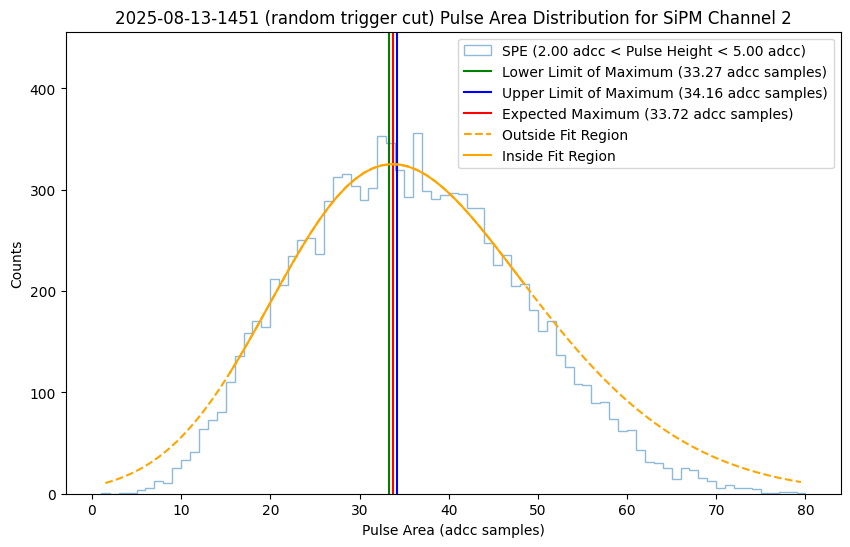

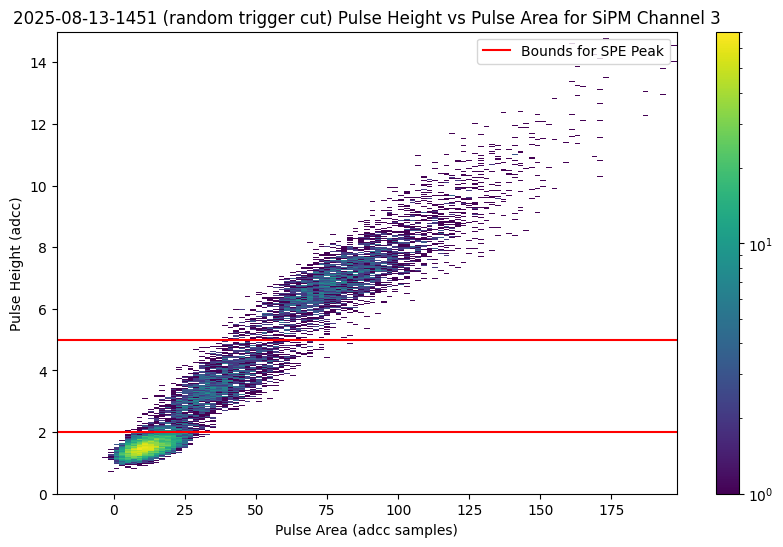

Parameter Errors from Self-Made Hessian Func
[[ 1.68313079e+00 -1.73446674e+00  1.52098531e+01 -4.51263567e-01]
 [-1.73446674e+00  1.86935956e+00 -1.98670847e+01  4.75478500e-01]
 [ 1.52098530e+01 -1.98670845e+01 -2.25438041e+03 -3.88170402e+00]
 [-4.51263567e-01  4.75478500e-01 -3.88170404e+00  1.26067597e-01]]
Values for Parameters
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -31404.638675524697
        x: [ 2.354e+01  1.825e+01  9.222e+03  1.411e+00]
      nit: 70
      jac: [ 9.766e-04  9.766e-04  2.441e-04 -1.465e-03]
 hess_inv: [[ 2.116e+02 -2.160e+02 -3.771e+02 -5.754e+01]
            [-2.160e+02  2.205e+02  3.848e+02  5.874e+01]
            [-3.771e+02  3.848e+02  6.743e+02  1.025e+02]
            [-5.754e+01  5.874e+01  1.025e+02  1.565e+01]]
     nfev: 641
     njev: 126
Error Bar Range on Maximum - 1.07
Lower Boundary - 32.8775
Upper Boundary - 33.9463


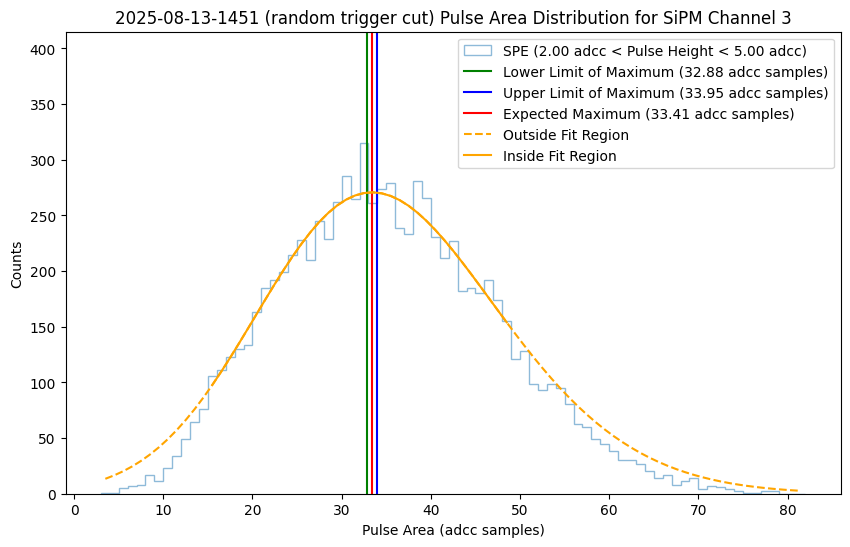

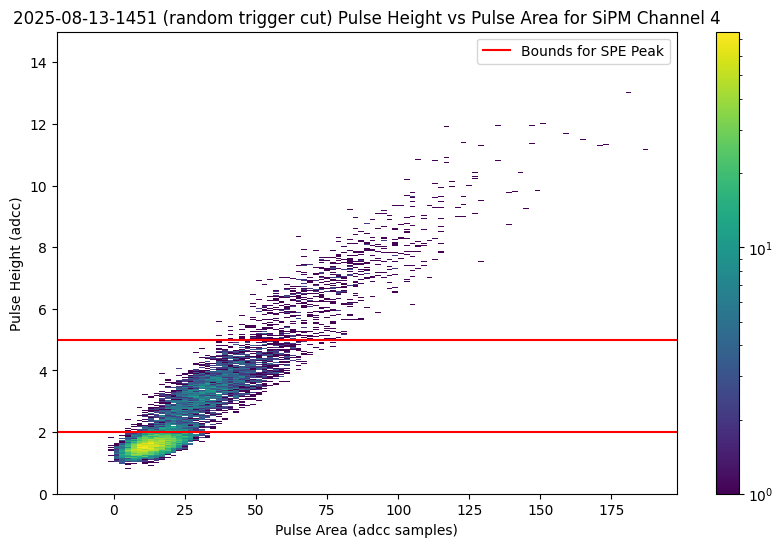

Parameter Errors from Self-Made Hessian Func
[[ 2.14335246e-01 -3.88612668e-01 -1.09966014e+00 -1.59299804e-01]
 [-3.88612668e-01  8.48140240e-01  2.13733542e+00  3.48068080e-01]
 [-1.09966013e+00  2.13733541e+00  1.44182952e+03 -1.02110441e-01]
 [-1.59299804e-01  3.48068080e-01 -1.02110441e-01  1.58378540e-01]]
Values for Parameters
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -52419.48135541013
        x: [ 1.817e+01  2.084e+01  1.391e+04  2.359e+00]
      nit: 58
      jac: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 hess_inv: [[ 3.102e-02  7.331e-04 -4.150e-02  9.390e-03]
            [ 7.331e-04  6.176e-02 -8.966e-02  7.841e-03]
            [-4.150e-02 -8.966e-02  2.710e-01 -2.840e-02]
            [ 9.390e-03  7.841e-03 -2.840e-02  7.857e-03]]
     nfev: 360
     njev: 72
Error Bar Range on Maximum - 0.88
Lower Boundary - 28.3956
Upper Boundary - 29.2796


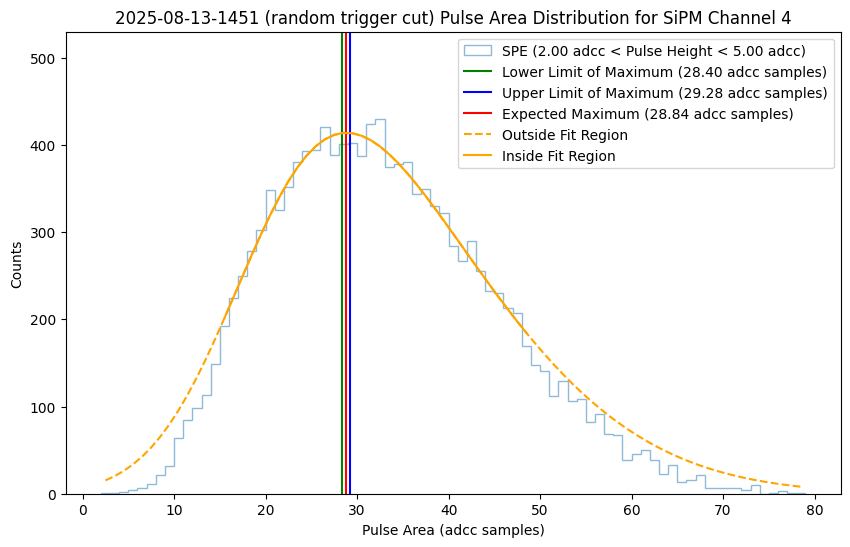

In [81]:
# How the channels are associated with the arrays
# This does need to be changed for real data, commented below is the correspondance for real data
# List below that is the 1-to-1 correspondance for the simulated data
channelList = [0, 2, 1, 3]
titleChans = [1, 2, 3, 4]
# channelList = [0, 1, 2, 3]
# titleChans = [1, 2, 3, 4]


# Define fit cutoffs
lowerPulseAreaCutoffs = [20, 15, 15, 15]
upperPulseAreaCutoffs = [50, 50, 50, 50]

lowerPulseHeightCutoffs = [2, 2, 2, 2]
upperPulseHeightCutoffs = [5, 5, 5, 5]

# mu, sigma, numOfValues, skew
fitGuesses = [[30, 15, 11000, 1],[35, 14, 12000, 1],[24, 15, 11000, 1],[24, 18, 13000, 2]]

# Produce
for i in range(len(channelList)):
    comparePulseAreaAndHeight(processedData, "2025-08-13-1451 (random trigger cut)", [1.6, 1.6, 1.6, 1.6], channelList, [lowerPulseHeightCutoffs[i], upperPulseHeightCutoffs[i]], channelList[i], titleChans[i], lowerPulseAreaCutoffs[i], upperPulseAreaCutoffs[i], fitGuesses[i])